# 03 Linear learner (Ridge Regression)

**Iteración:** 1 Primer modelo de ML real

## Objetivo

Entrenar un modelo lineal regularizado (Ridge) con las features básicas que entrega el ETL de R3, sin feature engineering adicional. Esta iteración valida que cualquier modelo de ML supera al baseline ingenuo y establece un nuevo punto de referencia para los modelos no lineales.

## Justificación del algoritmo

Se elige **Ridge Regression** (`sklearn.linear_model.Ridge`) por las siguientes razones:

1. **Equivalente al Linear Learner de SageMaker**: misma familia de algoritmos, lineales con regularización, implementado de forma local en el notebook.
2. **Regularización L2**: evita el sobreajuste a features con escalas grandes (como `Year` o `Store` que no fueron escaladas).
3. **Rápido y reproducible**: entrena en segundos sobre el dataset de 591k filas, ideal para una iteración inicial.
4. **Interpretable**: los coeficientes permiten entender qué features tienen más peso en la predicción.

## Features utilizadas

Se descartan `Sales`, variable target, `Customers`, `Date`.
Resto de columnas se usan tal cual las dejó el ETL de R3.

In [1]:
!pip install seaborn

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import BytesIO

from sklearn.linear_model import Ridge

# Configuración
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 100)

print("Imports cargados")

Imports cargados


In [3]:
# Carga de datos desde S3
BUCKET_NAME = "prediccion-demanda-processed-319501512128"
PREFIX_SPLITS = "rossmann/splits/"
TIMESTAMP = "20260410_054619"

s3_client = boto3.client("s3")

def load_csv_from_s3(bucket, key):
    response = s3_client.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(BytesIO(response["Body"].read()))

print("Cargando splits...")
df_train = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}train_{TIMESTAMP}.csv")
df_val = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}validation_{TIMESTAMP}.csv")
df_test = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}test_{TIMESTAMP}.csv")

for df in [df_train, df_val, df_test]:
    df["Date"] = pd.to_datetime(df["Date"])

print(f"Train: {df_train.shape}")
print(f"Val:   {df_val.shape}")
print(f"Test:  {df_test.shape}")

# Métricas reutilizables
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def evaluate(y_true, y_pred, label=""):
    metrics = {
        "RMSPE": rmspe(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
    }
    if label:
        print(f"{label}")
    print(f"   RMSPE: {metrics['RMSPE']:.4f}  ({metrics['RMSPE']*100:.2f}%)")
    print(f"   RMSE:  {metrics['RMSE']:.2f} €")
    print(f"   MAE:   {metrics['MAE']:.2f} €")
    return metrics

Cargando splits...
Train: (591036, 20)
Val:   (126651, 20)
Test:  (126651, 20)


In [4]:
# Selección de features
TARGET = "Sales"
EXCLUDE = ["Sales", "Customers", "Date"]

FEATURES = [c for c in df_train.columns if c not in EXCLUDE]

print(f"Target: {TARGET}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

# Construcción de matrices X / y
X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values

X_val = df_val[FEATURES].values
y_val = df_val[TARGET].values

X_test = df_test[FEATURES].values
y_test = df_test[TARGET].values

print(f"\nX_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  |  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  |  y_test:  {y_test.shape}")

Target: Sales
Features (17): ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Week', 'DayOfYear']

X_train: (591036, 17)  |  y_train: (591036,)
X_val:   (126651, 17)  |  y_val:   (126651,)
X_test:  (126651, 17)  |  y_test:  (126651,)


In [5]:
# Entrenamiento Ridge
import time

print("Entrenando modelo Ridge...")
t0 = time.time()

model_ridge = Ridge(
    alpha=1.0,           # regularización L2
    random_state=42,
)
model_ridge.fit(X_train, y_train)

train_time = time.time() - t0
print(f"Modelo entrenado en {train_time:.2f} segundos")

# Hiperparámetros usados
print("\nHiperparámetros:")
print(f"  alpha (regularización L2): {model_ridge.alpha}")
print(f"  fit_intercept: {model_ridge.fit_intercept}")
print(f"  solver: {model_ridge.solver}")

Entrenando modelo Ridge...
Modelo entrenado en 0.37 segundos

Hiperparámetros:
  alpha (regularización L2): 1.0
  fit_intercept: True
  solver: auto


In [9]:
# Predicciones y métricas en validation
y_pred_val = model_ridge.predict(X_val)

# Las predicciones lineales pueden ser negativas, las recortamos a 0
y_pred_val = np.clip(y_pred_val, 0, None)

print("=" * 60)
metrics_ridge_val = evaluate(y_val, y_pred_val, label="RIDGE Validation")
print("=" * 60)

# Comparación con baseline
print("\nComparación con baseline ingenuo:")
baseline_rmspe = 0.3803
improvement = (baseline_rmspe - metrics_ridge_val["RMSPE"]) / baseline_rmspe * 100
print(f"   Baseline RMSPE: {baseline_rmspe:.4f}  ({baseline_rmspe*100:.2f}%)")
print(f"   Ridge RMSPE:    {metrics_ridge_val['RMSPE']:.4f}  ({metrics_ridge_val['RMSPE']*100:.2f}%)")
print(f"   Mejora:         {improvement:+.1f}%")

RIDGE Validation
   RMSPE: 0.5908  (59.08%)
   RMSE:  2917.27 €
   MAE:   2100.05 €

Comparación con baseline ingenuo:
   Baseline RMSPE: 0.3803  (38.03%)
   Ridge RMSPE:    0.5908  (59.08%)
   Mejora:         -55.4%


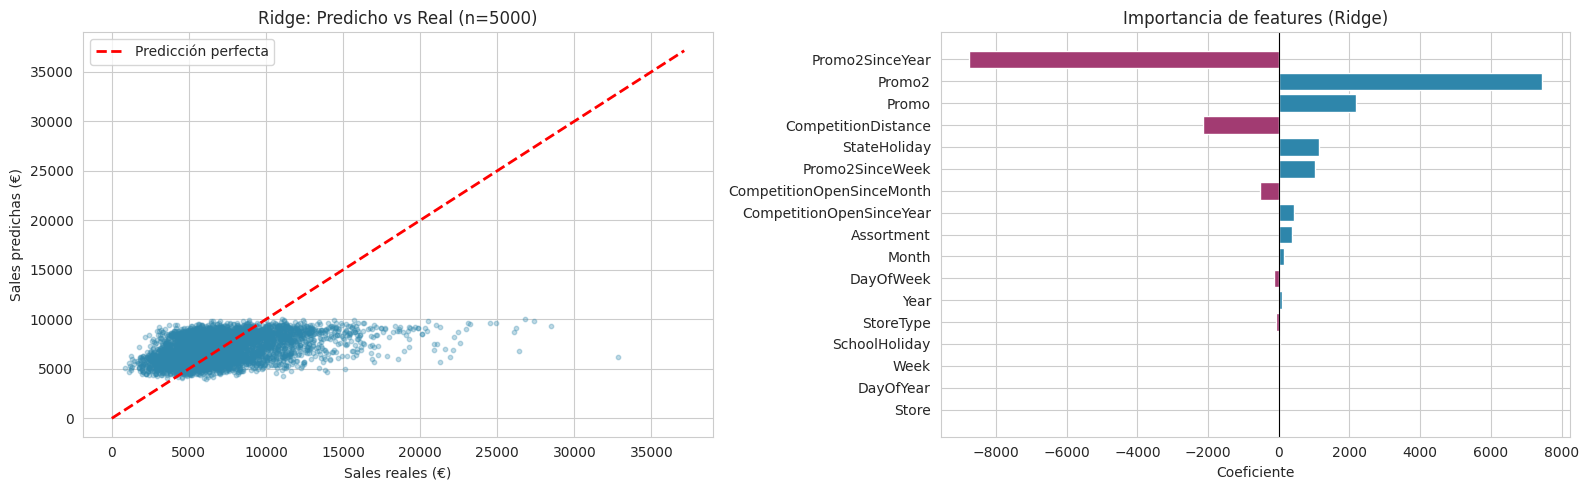


Top 5 features con mayor peso absoluto:
            Feature  Coefficient
    Promo2SinceYear -8753.885245
             Promo2  7441.086112
              Promo  2172.933021
CompetitionDistance -2136.708305
       StateHoliday  1144.316876


In [7]:
# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter predicho vs real
sample_idx = np.random.choice(len(y_val), 5000, replace=False)
axes[0].scatter(y_val[sample_idx], y_pred_val[sample_idx], alpha=0.3, s=10, color="#2E86AB")
max_val = max(y_val.max(), y_pred_val.max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Predicción perfecta")
axes[0].set_xlabel("Sales reales (€)")
axes[0].set_ylabel("Sales predichas (€)")
axes[0].set_title("Ridge: Predicho vs Real (n=5000)")
axes[0].legend()

# Coeficientes del modelo
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": model_ridge.coef_
}).sort_values("Coefficient", key=abs, ascending=True)

colors = ["#A23B72" if c < 0 else "#2E86AB" for c in coef_df["Coefficient"]]
axes[1].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Coeficiente")
axes[1].set_title("Importancia de features (Ridge)")

plt.tight_layout()
plt.savefig("../results/plots/ridge_results.png", dpi=120, bbox_inches="tight")
plt.show()

# Top 5 features con más peso
print("\nTop 5 features con mayor peso absoluto:")
top5 = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index).head(5)
print(top5.to_string(index=False))

In [8]:
# Guardar métricas en la tabla comparativa
import os
results_path = "../results/metrics_comparison.csv"

new_row = pd.DataFrame([{
    "Iteration": 1,
    "Model": "Ridge Regression (alpha=1.0)",
    "Split": "Validation",
    "RMSPE": metrics_ridge_val["RMSPE"],
    "RMSE": metrics_ridge_val["RMSE"],
    "MAE": metrics_ridge_val["MAE"],
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Iteration"] != 1]
    results_df = pd.concat([existing, new_row], ignore_index=True).sort_values("Iteration")
else:
    results_df = new_row

results_df.to_csv(results_path, index=False)

print("Métricas guardadas")
print("\nTabla comparativa actualizada:")
print(results_df.to_string(index=False))

Métricas guardadas

Tabla comparativa actualizada:
 Iteration                                    Model      Split    RMSPE        RMSE         MAE
         0 Baseline Ingenuo (media Store×DayOfWeek) Validation 0.380258 1850.471558 1325.987539
         1             Ridge Regression (alpha=1.0) Validation 0.590811 2917.271294 2100.046361


## Resultados de la iteración 1

| Métrica | Baseline ingenuo | Ridge | Cambio |
|---------|------------------|-------|--------|
| RMSPE   | 38.03%           | 59.08% | **+55% peor** |
| RMSE    | 1.850 €          | 2.917 € | **+57% peor** |
| MAE     | 1.326 €          | 2.100 € | **+58% peor** |

### Hallazgo crítico: Ridge empeora respecto al baseline

Contra lo esperable, Ridge no solo no mejora la predicción ingenua sino que **la degrada un 55% en RMSPE**. Lejos de ser un fracaso, este resultado es **un hallazgo metodológico relevante** que justifica el cambio de algoritmo en la siguiente iteración.

### Diagnóstico

Analizando el gráfico de "predicho vs real" se observa que las predicciones de Ridge **se concentran en una banda estrecha (5.000–10.000 €)** sin discriminar la magnitud real de las ventas. La causa raíz se encuentra en el ranking de coeficientes:

- Los pesos absolutos más altos (`Promo2SinceYear ≈ −8.754`, `Promo2 ≈ +7.441`) son desproporcionadamente grandes y de signo contrario, lo que indica que el modelo intenta compensar una mala representación de los datos.
- Variables categóricas como `Store` (1-1115), `StoreType` (1-3) o `StateHoliday` (0-3) están codificadas como enteros y Ridge las interpreta como **magnitudes continuas con orden**, lo que es semánticamente incorrecto: la tienda 1115 no es "1115 veces más grande" que la tienda 1.
- Ridge, al ser un modelo **lineal**, no puede capturar interacciones (por ejemplo, "el efecto de `Promo` depende del `DayOfWeek`") ni estructuras no lineales presentes en los datos.

### Mitigación: cambio de familia de algoritmos

Para resolver estas limitaciones, la siguiente iteración usa **XGBoost (gradient boosting sobre árboles)**, que:

1. Trata variables categóricas codificadas como enteros sin asumir orden ni magnitud.
2. Captura interacciones entre features de forma nativa.
3. Modela relaciones no lineales sin necesidad de transformaciones manuales.